In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from mne.decoding import CSP
import mne
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import mlflow
import mlflow.sklearn

sys.path.append(os.path.abspath(os.path.join('..')))

from src.train_BCICIV import train_BCICIV
from src.load_data_BCICIV import load_all_subjects
from src.preprocess import normalize_trial


mne.set_log_level('WARNING')

## LOAD TRAIN DATA FOR BCICIV DATASET

In [2]:
data_path = '../datasets/BCICIV_2a_gdf'
data_22 = load_all_subjects(data_path, channels_to_use='all')
data_11 = load_all_subjects(data_path)

/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A01T.gdf


/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A02T.gdf


/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

Loaded file: ../datasets/BCICIV_2a_gdf/A07T.gdf


/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A08T.gdf


/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A09T.gdf


In [3]:
split_index = 1006  

X_train_22 = data_22['X'][:split_index]
y_train_22 = data_22['y'][:split_index]
subject_ids_train_22 = data_22['subject_ids'][:split_index]

X_test_22 = data_22['X'][split_index:]
y_test_22 = data_22['y'][split_index:]
subject_ids_test_22 = data_22['subject_ids'][split_index:]

X_train_11 = data_11['X'][:split_index]
y_train_11 = data_11['y'][:split_index]
subject_ids_train_11 = data_11['subject_ids'][:split_index]

X_test_11 = data_11['X'][split_index:]
y_test_11 = data_11['y'][split_index:]
subject_ids_test_11 = data_11['subject_ids'][split_index:]

In [4]:
models = {
    'model': [],
    'score': [],
    'name': []
}

# 22 channels (raw + normalization)

## CSP + LDA MODEL

In [5]:
norm_transformer = FunctionTransformer(normalize_trial)

def to_float64(X):
    return X.astype(np.float64)

to_float64 = FunctionTransformer(to_float64)


In [6]:
pipe1 = Pipeline([
    ('to_float64', to_float64),
    ('norm', norm_transformer),
    ('csp', CSP(log=True, norm_trace=False)),
    ('clf', LinearDiscriminantAnalysis())
])

param_grid1 = {
    'csp__n_components': [2, 4],
    'csp__reg': ['ledoit_wolf', 'oas'],
    'clf__solver': ['svd', 'lsqr']
}

In [7]:
model, params, best_score = train_BCICIV(X_train_22, y_train_22, subject_ids_train_22, pipe1, param_grid1)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_raw_LDA')

Best score: 0.5487498612498612


## CSP + SVM MODEL

In [8]:
pipe2 = Pipeline([
    ('to_float64', to_float64),
    ('norm', norm_transformer),
    ('csp', CSP(log=True, norm_trace=False)),
    ('clf', SVC(kernel='rbf'))
])

param_grid2 = {
    'csp__n_components': [2, 4],
    'csp__reg': ['ledoit_wolf', 'oas'],
    'clf__C': [0.5, 1, 5],
    'clf__gamma': ['scale']
}

In [9]:
model, params, best_score = train_BCICIV(X_train_22, y_train_22, subject_ids_train_22, pipe2, param_grid2)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_raw_SVM')

Best score: 0.5467310467310468


# 22 channels (only mu band)

In [10]:
data_22_mu_beta = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)], channels_to_use='all')

/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/

In [11]:
X_train_22_mu_beta = data_22_mu_beta['X'][:split_index]
y_train_22_mu_beta = data_22_mu_beta['y'][:split_index]
subject_ids_train_22_mu_beta = data_22_mu_beta['subject_ids'][:split_index]

X_test_22_mu_beta = data_22_mu_beta['X'][split_index:]
y_test_22_mu_beta = data_22_mu_beta['y'][split_index:]
subject_ids_test_22_mu_beta = data_22_mu_beta['subject_ids'][split_index:]

X_train_22_mu = np.copy(X_train_22_mu_beta[:, 0, :, :])
y_train_22_mu = np.copy(y_train_22_mu_beta)
subject_ids_train_22_mu = np.copy(subject_ids_train_22_mu_beta)

X_test_22_mu = np.copy(X_test_22_mu_beta[:, 0, :, :])
y_test_22_mu = np.copy(y_test_22_mu_beta)
subject_ids_test_22_mu = np.copy(subject_ids_test_22_mu_beta)

## CSP + LDA MODEL

In [12]:
model, params, best_score = train_BCICIV(X_train_22_mu, y_train_22_mu, subject_ids_train_22_mu, pipe1, param_grid1)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_mu_LDA')

Best score: 0.5258630258630258


## CSP + SVM MODEL

In [13]:
model, params, best_score = train_BCICIV(X_train_22_mu, y_train_22_mu, subject_ids_train_22_mu, pipe2, param_grid2)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_mu_SVM')

Best score: 0.5367965367965367


# 22 channels (mu + beta band)

In [14]:
trials, bands, channels, samples = X_train_22_mu_beta.shape
X_train_22_mu_beta = X_train_22_mu_beta.reshape(trials, bands * channels, samples)

print("Processed multi-band data shape:", X_train_22_mu_beta.shape)

Processed multi-band data shape: (1006, 44, 1000)


## CSP + LDA MODEL

In [15]:
model, params, best_score = train_BCICIV(X_train_22_mu_beta, y_train_22_mu_beta, subject_ids_train_22_mu_beta, pipe1, param_grid1)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_mu_beta_LDA')

Best score: 0.5587121212121212


## CSP + SVM MODEL

In [16]:
model, params, best_score = train_BCICIV(X_train_22_mu_beta, y_train_22_mu_beta, subject_ids_train_22_mu_beta, pipe2, param_grid2)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('22_ch_mu_beta_SVM')

Best score: 0.5447538572538572


# 11 channels (raw + normalization)

## CSP + LDA MODEL

In [17]:
model, params, best_score = train_BCICIV(X_train_11, y_train_11, subject_ids_train_11, pipe1, param_grid1)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_raw_LDA')

Best score: 0.5675643800643801


## CSP + SVM MODEL

In [18]:
model, params, best_score = train_BCICIV(X_train_11, y_train_11, subject_ids_train_11, pipe2, param_grid2)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_raw_SVM')

Best score: 0.5457251082251082


# 11 channels (only mu band)

In [19]:
data_11_mu_beta = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)])

/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/

In [20]:
X_train_11_mu_beta = data_11_mu_beta['X'][:split_index]
y_train_11_mu_beta = data_11_mu_beta['y'][:split_index]
subject_ids_train_11_mu_beta = data_11_mu_beta['subject_ids'][:split_index]

X_test_11_mu_beta = data_11_mu_beta['X'][split_index:]
y_test_11_mu_beta = data_11_mu_beta['y'][split_index:]
subject_ids_test_11_mu_beta = data_11_mu_beta['subject_ids'][split_index:]

X_train_11_mu = np.copy(X_train_11_mu_beta[:, 0, :, :])
y_train_11_mu = np.copy(y_train_11_mu_beta)
subject_ids_train_11_mu = np.copy(subject_ids_train_11_mu_beta)

X_test_11_mu = np.copy(X_test_11_mu_beta[:, 0, :, :])
y_test_11_mu = np.copy(y_test_11_mu_beta)
subject_ids_test_11_mu = np.copy(subject_ids_test_11_mu_beta)

## CSP + LDA MODEL

In [21]:
model, params, best_score = train_BCICIV(X_train_11_mu, y_train_11_mu, subject_ids_train_11_mu, pipe1, param_grid1)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_mu_LDA')

Best score: 0.5297757797757797


## CSP + SVM MODEL

In [22]:
model, params, best_score = train_BCICIV(X_train_11_mu, y_train_11_mu, subject_ids_train_11_mu, pipe2, param_grid2)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_mu_SVM')

Best score: 0.5297827172827173


# 11 channels (mu + beta band)

In [23]:
trials, bands, channels, samples = X_train_11_mu_beta.shape
X_train_11_mu_beta = X_train_11_mu_beta.reshape(trials, bands * channels, samples)

print("Processed multi-band data shape:", X_train_11_mu_beta.shape)

Processed multi-band data shape: (1006, 22, 1000)


## CSP + LDA MODEL

In [24]:
model, params, best_score = train_BCICIV(X_train_11_mu_beta, y_train_11_mu_beta, subject_ids_train_11_mu_beta, pipe1, param_grid1)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_mu_beta_LDA')

Best score: 0.5745643245643246


## CSP + SVM MODEL

In [25]:
model, params, best_score = train_BCICIV(X_train_11_mu_beta, y_train_11_mu_beta, subject_ids_train_11_mu_beta, pipe2, param_grid2)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('11_ch_mu_beta_SVM')

Best score: 0.5596556221556223


# 2 channels (C3 + C4 - Only mu band)

In [30]:
channels_to_use = [3, 7] # C3 and C4
data_2ch = np.copy(data_11_mu_beta['X'])
X_2ch_train = data_2ch[:split_index, 0, channels_to_use, :]
X_2ch_test = data_2ch[split_index:, 0, channels_to_use, :]


In [31]:
print("Data shapes:")
print("Original data:", X_train_11.shape)
print("2-channel data train:", X_2ch_train.shape)
print("2-channel data test:", X_2ch_test.shape)

Data shapes:
Original data: (1006, 11, 1000)
2-channel data train: (1006, 2, 1000)
2-channel data test: (288, 2, 1000)


## CSP + LDA MODEL

In [32]:
model, params, best_score = train_BCICIV(X_2ch_train, y_train_11_mu, subject_ids_train_11_mu, pipe1, param_grid1)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('2ch_mu_LDA')

Best score: 0.5110098235098236


## CSP + SVM MODEL

In [33]:
model, params, best_score = train_BCICIV(X_2ch_train, y_train_11_mu, subject_ids_train_11_mu, pipe2, param_grid2)
print(f"Best score: {best_score}")
models['model'].append(model)
models['score'].append(best_score)
models['name'].append('2ch_mu_SVM')

Best score: 0.5109681984681985


# Results

In [34]:
best_model_index = np.argmax(models['score'])
best_model = models['model'][best_model_index]
best_model_name = models['name'][best_model_index]
print(f"Best model: {best_model_name} with score {models['score'][best_model_index]}")

Best model: 11_ch_mu_beta_LDA with score 0.5745643245643246


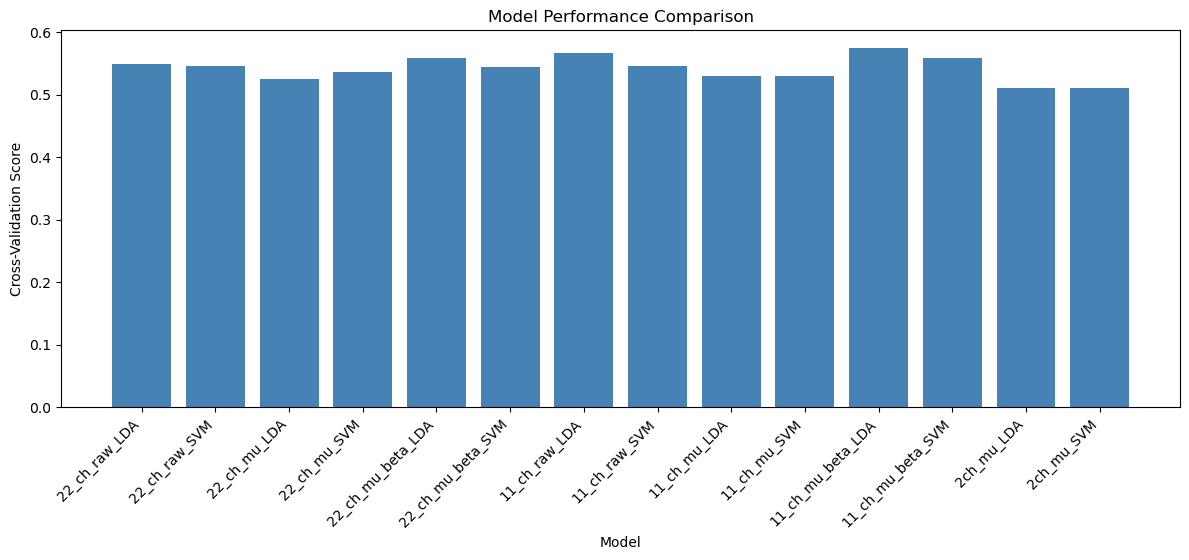

In [49]:
plt.figure(figsize=(12, 6))
plt.bar(models['name'], models['score'], color='steelblue')
plt.xlabel('Model')
plt.ylabel('Cross-Validation Score')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)

# Why not to try laplacian filter?

The Laplacian filter is a spatial filter that highlights local differences between electrodes. It is often applied over C3 and C4, where hand-movement activity is most clear. However, when using CSP, it usually does not improve model performance. This is because CSP finds linear combinations of all channels that maximize variance between classes while minimizing variance within each class. In other words, CSP already learns optimal spatial filters from the data, so the Laplacian filter is generally unnecessary.